In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline

In [4]:
df =pd.read_csv("D:\\apexplanet-data-analytics\\data\\cleaned_superstore.csv")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9011 non-null   int64  
 1   Order ID        9011 non-null   object 
 2   Order Date      9011 non-null   object 
 3   Ship Date       9011 non-null   object 
 4   Ship Mode       9011 non-null   object 
 5   Customer ID     9011 non-null   object 
 6   Customer Name   9011 non-null   object 
 7   Segment         9011 non-null   object 
 8   Country/Region  9011 non-null   object 
 9   City            9011 non-null   object 
 10  State/Province  9011 non-null   object 
 11  Postal Code     9011 non-null   object 
 12  Region          9011 non-null   object 
 13  Product ID      9011 non-null   object 
 14  Category        9011 non-null   object 
 15  Sub-Category    9011 non-null   object 
 16  Product Name    9011 non-null   object 
 17  Sales           9011 non-null   f

In [7]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,9011.000000,9011.000000,9011.000000,9011.000000,9011.000000
mean,5115.080901,92.443492,3.613472,0.156685,11.302683
std,2940.684063,113.773985,2.135185,0.211336,48.873552
min,1.000000,0.444000,1.000000,0.000000,-1181.282400
25%,2578.000000,15.100000,2.000000,0.000000,1.733400
50%,5129.000000,40.560000,3.000000,0.200000,7.482400
75%,7656.500000,123.029000,5.000000,0.200000,21.265700
max,10194.000000,497.610000,14.000000,0.800000,240.859500


In [8]:
df.shape

(9011, 21)

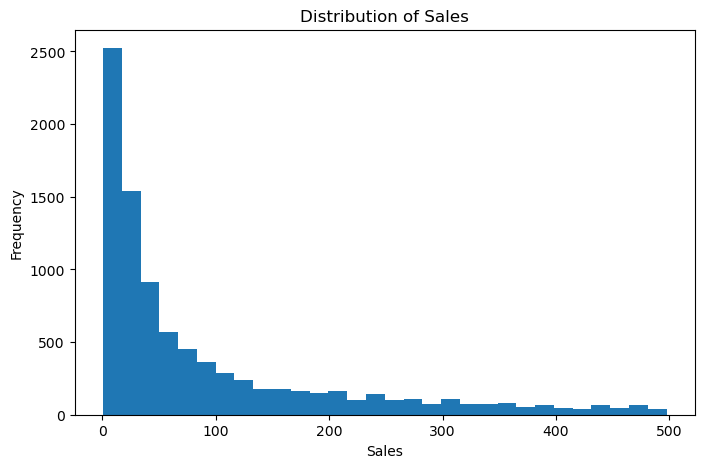

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.savefig("D:\\apexplanet-data-analytics\\visualization\\sales_histogram.png")
plt.show()

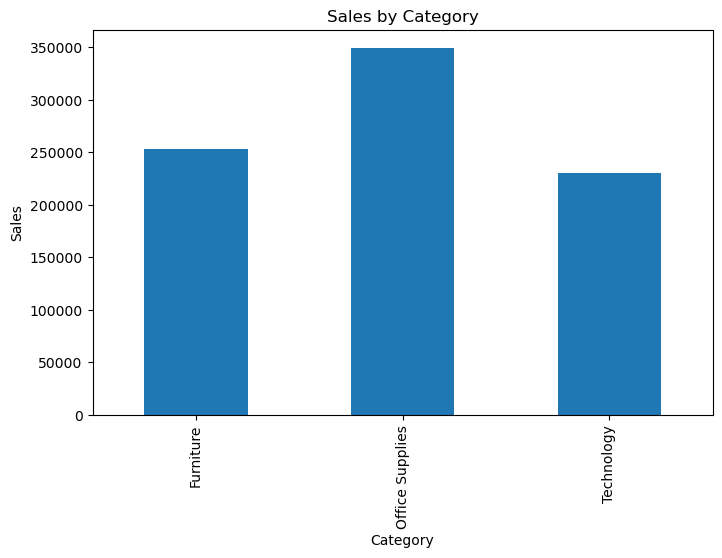

In [23]:
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.savefig("D:\\apexplanet-data-analytics\\visualization\\sales_category.png")
plt.show()

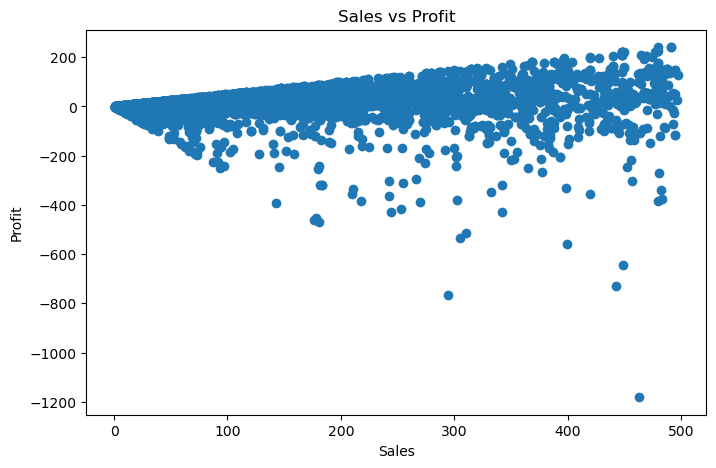

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'],df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.savefig("D:\\apexplanet-data-analytics\\visualization\\scatter_sales_profit.png")
plt.show()

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [18]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

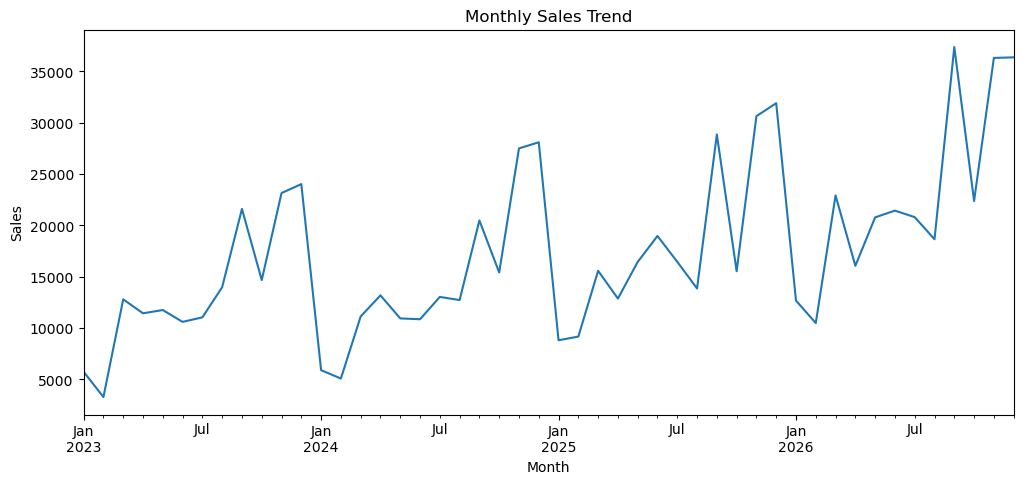

In [25]:
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("D:\\apexplanet-data-analytics\\visualization\\monthly_sales.png")
plt.show()

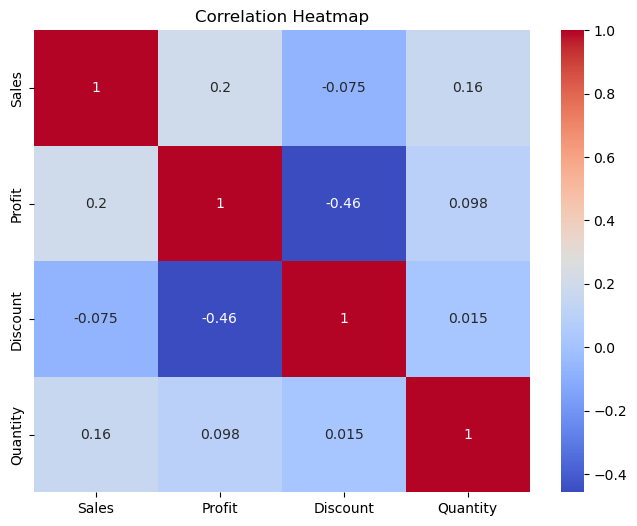

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Sales','Profit','Discount','Quantity']].corr(),
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("D:\\apexplanet-data-analytics\\visualization\\correlation_heatmap.png")
plt.show()

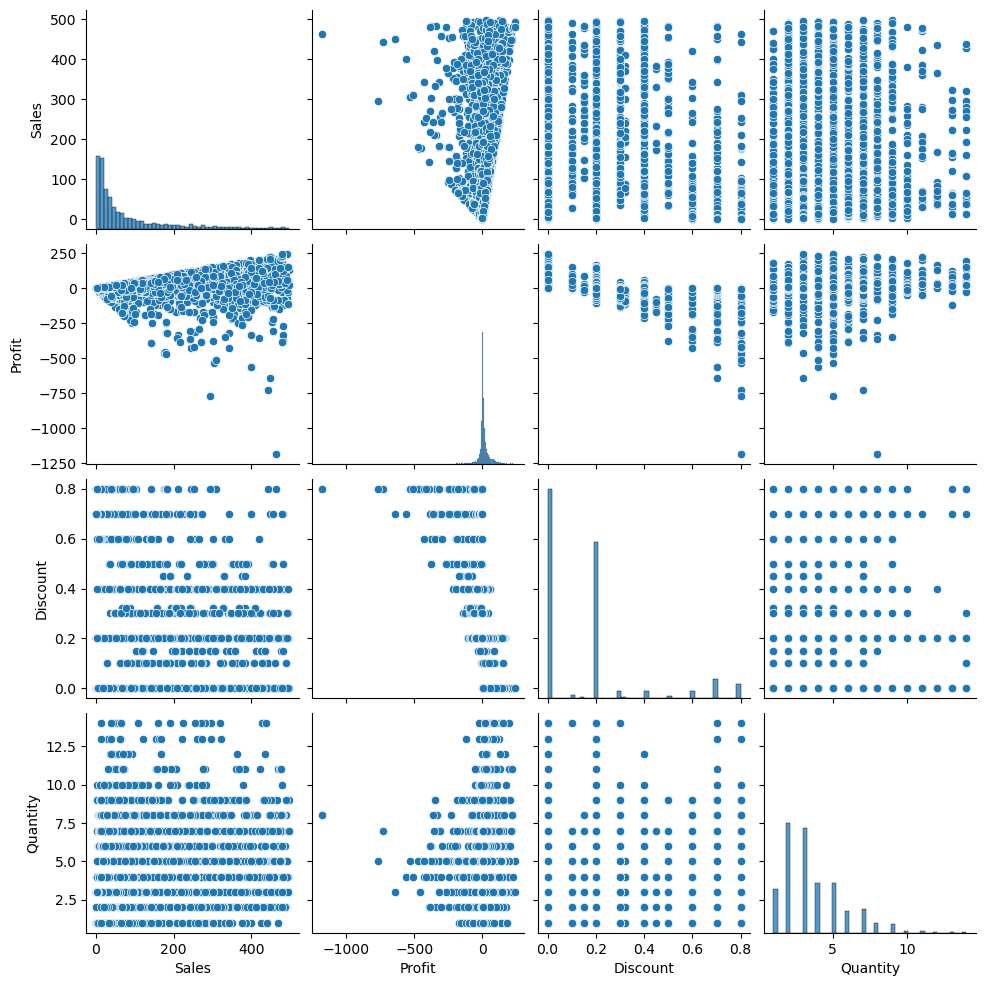

In [27]:
sns.pairplot(df[['Sales','Profit','Discount','Quantity']])
plt.savefig("D:\\apexplanet-data-analytics\\visualization\\pairplot.png")
plt.show()

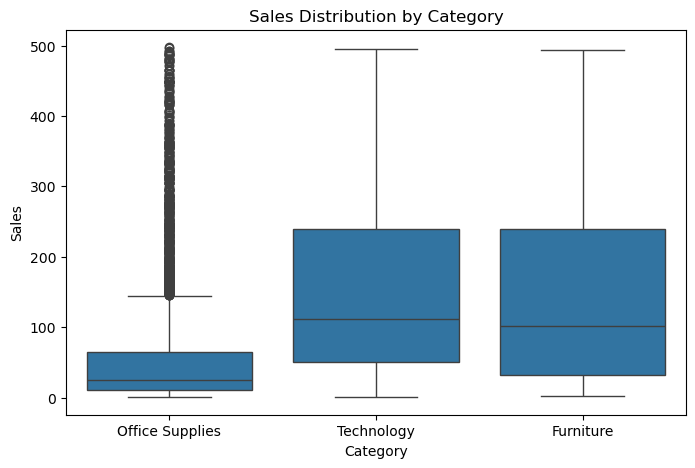

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Category',
    y='Sales',
    data=df
)
plt.title("Sales Distribution by Category")
plt.savefig("D:\\apexplanet-data-analytics\\visualization\\boxplot_sales.png")
plt.show()

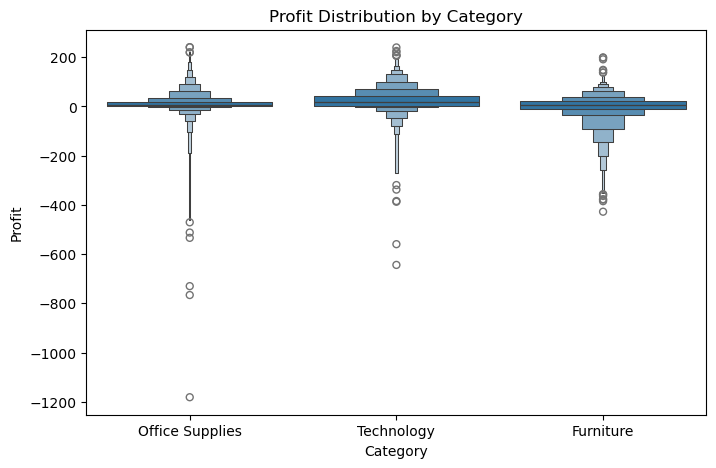

In [29]:
plt.figure(figsize=(8,5))
sns.boxenplot(
    x='Category',
    y='Profit',
    data=df
)
plt.title("Profit Distribution by Category")
plt.savefig("D:\\apexplanet-data-analytics\\visualization\\boxen_profit.png")
plt.show()

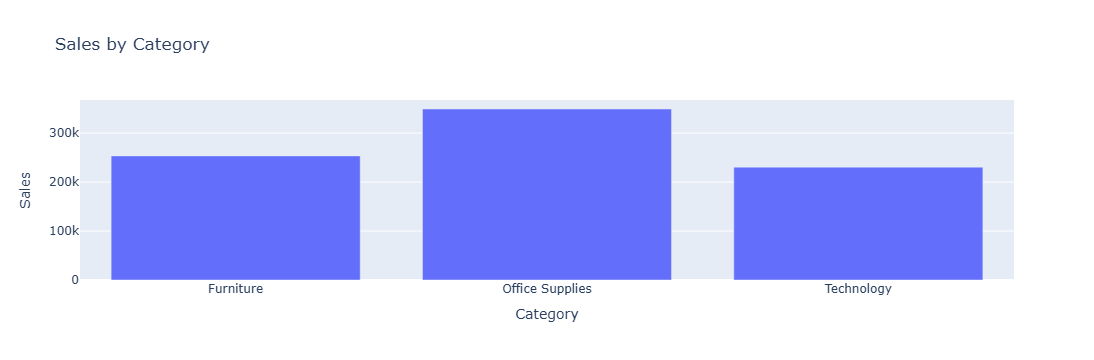

In [31]:
category_sales = df.groupby(
    'Category'
)['Sales'].sum().reset_index()
fig = px.bar(
    category_sales,
    x='Category',
    y='Sales',
    title='Sales by Category'
)
fig.show()

In [32]:
fig.write_html("D:\\apexplanet-data-analytics\\visualization\\sales_by_category.html")

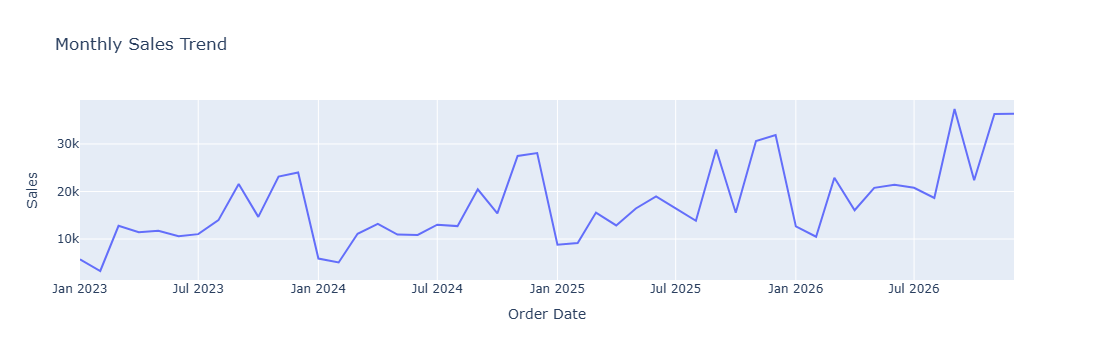

In [33]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)
fig = px.line(
    monthly_sales,
    x='Order Date',
    y='Sales',
    title='Monthly Sales Trend'
)
fig.show()

In [34]:
fig.write_html("D:\\apexplanet-data-analytics\\visualization\\monthly_sales_trend.html")